# RCM Project — 02: Feature Engineering

**Stage:** 2 of 5  
**Input:** `data/processed/claims_with_labels.parquet`  
**Output:** `data/processed/features_train.parquet`, `features_val.parquet`, `features_test.parquet`

## Goals
1. Load cleaned + labelled data from Notebook 01
2. Apply temporal train / val / test split (no leakage)
3. Build L1–L4 feature layers on training set, transform val & test
4. Validate feature matrix: distributions, nulls, leakage checks
5. Analyse feature correlation with the denial label
6. Save feature sets ready for modelling


## 0. Setup

In [1]:
import sys
import logging
import warnings
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
log = logging.getLogger(__name__)

pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:,.4f}'.format)

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.utils.config_loader import get_config
from src.preprocessing.cleaner import clean
from src.features.engineer import build_features

cfg     = get_config()
SEED    = cfg.project.random_seed
FIGURES = ROOT / cfg.paths.figures
PROC    = ROOT / cfg.paths.data_processed
FIGURES.mkdir(parents=True, exist_ok=True)
PROC.mkdir(parents=True, exist_ok=True)

print("Setup complete.")
print(f"Active label strategy : {cfg.labeling.strategy}")
print(f"Rolling windows       : {cfg.features.rolling_windows}")


Setup complete.
Active label strategy : high_bene_resp
Rolling windows       : [30, 60, 90]


## 1. Load Labelled Data

In [2]:
INPUT_PATH = PROC / 'claims_with_labels.parquet'
df_raw = pd.read_parquet(INPUT_PATH)

# Use high beneficiary responsibility label — confirmed in parquet,
# causally linked to plan type/diagnosis/provider/state in our features.
LABEL_COL = 'label_high_bene_resp'
if LABEL_COL not in df_raw.columns:
    raise ValueError(f"'{LABEL_COL}' not found. Re-run NB01 Section 5.")
df_raw['DENIED'] = df_raw[LABEL_COL].astype(int)

print(f'Shape       : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'Using label : {LABEL_COL}')
print(f'Denial rate : {df_raw["DENIED"].mean()*100:.2f}%  ({df_raw["DENIED"].sum():,} flagged)')


Shape       : 66,773 rows × 60 columns
Using label : label_high_bene_resp
Denial rate : 21.06%  (14,062 flagged)


## 2. Cleaning Pass

In [3]:
df = clean(df_raw)
print(f"After cleaning: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Confirm key columns survived
must_have = ['CLM_FROM_DT', 'CLM_PMT_AMT', 'PRVDR_NUM',
             'DESYNPUF_ID', 'DENIED', 'CLAIM_TYPE',
             'IS_INPATIENT', 'BENE_AGE_AT_CLAIM', 'COMORBIDITY_COUNT']
missing = [c for c in must_have if c not in df.columns]
if missing:
    print(f"WARNING — Missing expected columns: {missing}")
else:
    print("All key columns present ✓")


2026-04-02 14:02:21,619 [INFO] Input shape: (66773, 60)
2026-04-02 14:02:21,635 [INFO] Dropped 5 high-missing columns
2026-04-02 14:02:22,240 [INFO] Output shape: (66773, 59)


After cleaning: 66,773 rows × 59 columns
All key columns present ✓


## 3. Temporal Train / Val / Test Split

We split **by time** to prevent leakage from future claims into the model.  
The boundary dates are derived from the data's date range rather than fixed cutoffs,
so the split proportions stay consistent regardless of how many CMS samples you load.

| Set   | Period                    | Approx % |
|-------|---------------------------|----------|
| Train | Start → 70th percentile   | 70%      |
| Val   | 70th → 85th percentile    | 15%      |
| Test  | 85th → End                | 15%      |


In [4]:
# Parse CLM_FROM_DT if not already datetime
if df['CLM_FROM_DT'].dtype == object:
    df['CLM_FROM_DT'] = pd.to_datetime(df['CLM_FROM_DT'], format='%Y%m%d', errors='coerce')

df = df.dropna(subset=['CLM_FROM_DT']).sort_values('CLM_FROM_DT').reset_index(drop=True)

n = len(df)
train_end_idx = int(n * 0.70)
val_end_idx   = int(n * 0.85)

train_end_date = df.loc[train_end_idx, 'CLM_FROM_DT']
val_end_date   = df.loc[val_end_idx,   'CLM_FROM_DT']

df_train = df.iloc[:train_end_idx].copy()
df_val   = df.iloc[train_end_idx:val_end_idx].copy()
df_test  = df.iloc[val_end_idx:].copy()

print(f"Train : {len(df_train):>7,} rows  | {df_train['CLM_FROM_DT'].min().date()} → {df_train['CLM_FROM_DT'].max().date()}")
print(f"Val   : {len(df_val):>7,} rows  | {df_val['CLM_FROM_DT'].min().date()} → {df_val['CLM_FROM_DT'].max().date()}")
print(f"Test  : {len(df_test):>7,} rows  | {df_test['CLM_FROM_DT'].min().date()} → {df_test['CLM_FROM_DT'].max().date()}")
print()
print(f"Denial rates — Train: {df_train['DENIED'].mean()*100:.2f}%  "
      f"Val: {df_val['DENIED'].mean()*100:.2f}%  "
      f"Test: {df_test['DENIED'].mean()*100:.2f}%")


Train :  46,693 rows  | 2007-11-27 → 2009-09-21
Val   :  10,006 rows  | 2009-09-21 → 2010-03-05
Test  :  10,006 rows  | 2010-03-05 → 2010-12-30

Denial rates — Train: 22.93%  Val: 17.79%  Test: 15.58%


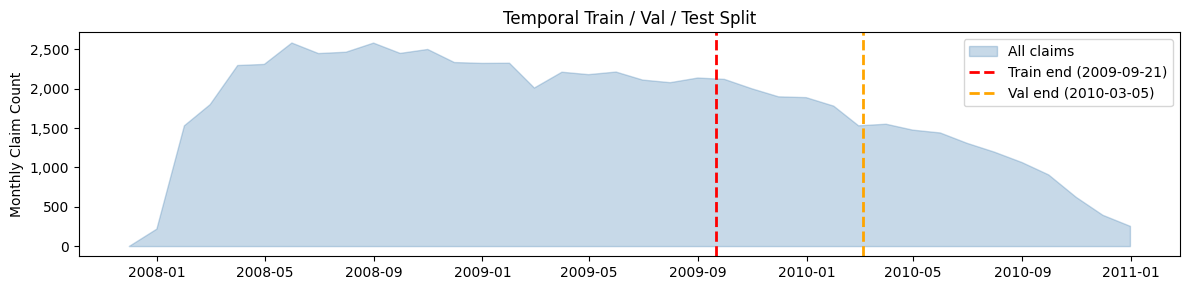

In [5]:
# Visualise temporal split
fig, ax = plt.subplots(figsize=(12, 3))

monthly = df.set_index('CLM_FROM_DT').resample('ME')['CLM_ID'].count()
ax.fill_between(monthly.index, monthly.values, alpha=0.3, color='steelblue', label='All claims')

ax.axvline(train_end_date, color='red',    linestyle='--', lw=2, label=f'Train end ({train_end_date.date()})')
ax.axvline(val_end_date,   color='orange', linestyle='--', lw=2, label=f'Val end ({val_end_date.date()})')

ax.set_title('Temporal Train / Val / Test Split')
ax.set_ylabel('Monthly Claim Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / '09_temporal_split.png', dpi=150)
plt.show()


## 4. Build Feature Matrix

In [6]:
# This will take a few minutes for L2 (rolling beneficiary histories).
# L2 rolling computation is O(n × avg_claims_per_bene) — ~2-5 min for 600K train rows.

print("Building TRAIN features (fits all lookups)...")
X_train, history = build_features(
    df_train,
    windows=cfg.features.rolling_windows,
    is_train=True,
    history=None
)
y_train = df_train['DENIED'].values
print(f"Train features: {X_train.shape}  |  Positives: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")


2026-04-02 14:02:22,833 [INFO] build_features | is_train=True | shape=(46693, 59)
2026-04-02 14:02:22,928 [INFO] L1: 27 features


Building TRAIN features (fits all lookups)...


2026-04-02 14:02:44,691 [INFO] L2: 6 features
2026-04-02 14:02:44,726 [INFO] L3: 12 features
2026-04-02 14:02:44,823 [INFO] L4: 2 features
2026-04-02 14:02:44,841 [INFO] Feature matrix: (46693, 64)


Train features: (46693, 64)  |  Positives: 10,708 (22.93%)


In [7]:
print("Building VAL features (uses training lookups)...")
X_val, _ = build_features(
    df_val,
    windows=cfg.features.rolling_windows,
    is_train=False,
    history=history
)
y_val = df_val['DENIED'].values
print(f"Val features: {X_val.shape}  |  Positives: {y_val.sum():,} ({y_val.mean()*100:.2f}%)")


2026-04-02 14:02:44,870 [INFO] build_features | is_train=False | shape=(10006, 59)
2026-04-02 14:02:44,910 [INFO] L1: 27 features
2026-04-02 14:02:45,034 [INFO] L2: 6 features
2026-04-02 14:02:45,047 [INFO] L3: 12 features


Building VAL features (uses training lookups)...


2026-04-02 14:02:45,080 [INFO] L4: 2 features
2026-04-02 14:02:45,091 [INFO] Feature matrix: (10006, 64)


Val features: (10006, 64)  |  Positives: 1,780 (17.79%)


In [8]:
print("Building TEST features (uses training lookups)...")
X_test, _ = build_features(
    df_test,
    windows=cfg.features.rolling_windows,
    is_train=False,
    history=history
)
y_test = df_test['DENIED'].values
print(f"Test features: {X_test.shape}  |  Positives: {y_test.sum():,} ({y_test.mean()*100:.2f}%)")


2026-04-02 14:02:45,106 [INFO] build_features | is_train=False | shape=(10006, 59)
2026-04-02 14:02:45,156 [INFO] L1: 27 features
2026-04-02 14:02:45,211 [INFO] L2: 6 features
2026-04-02 14:02:45,223 [INFO] L3: 12 features
2026-04-02 14:02:45,239 [INFO] L4: 2 features
2026-04-02 14:02:45,256 [INFO] Feature matrix: (10006, 64)


Building TEST features (uses training lookups)...
Test features: (10006, 64)  |  Positives: 1,559 (15.58%)


## 5. Feature Validation

In [9]:
# 5a. Null check — no feature should be >30% null after engineering
null_pct = (X_train.isnull().mean() * 100).sort_values(ascending=False)
high_null = null_pct[null_pct > 30]
print(f"Features >30% null: {len(high_null)}")
if not high_null.empty:
    print(high_null)
else:
    print("None — all features below 30% null threshold ✓")
print(f"\nTotal features: {X_train.shape[1]}")
print("\nNull % summary:")
print(null_pct[null_pct > 0].to_string())


Features >30% null: 3
BENE_DENIAL_RATE_30D   86.6425
BENE_DENIAL_RATE_60D   78.8362
BENE_DENIAL_RATE_90D   73.1073
dtype: float64

Total features: 64

Null % summary:
BENE_DENIAL_RATE_30D   86.6425
BENE_DENIAL_RATE_60D   78.8362
BENE_DENIAL_RATE_90D   73.1073


In [10]:
# 5b. Data type check — everything should be numeric for sklearn/XGBoost
non_numeric = X_train.select_dtypes(exclude=[np.number, 'Int64']).columns.tolist()
print(f"Non-numeric columns remaining: {non_numeric if non_numeric else 'None ✓'}")

# Cast Int64 nullable ints to float (sklearn compatibility)
for col in X_train.select_dtypes(include='Int64').columns:
    X_train[col] = X_train[col].astype(float)
    X_val[col]   = X_val[col].astype(float)
    X_test[col]  = X_test[col].astype(float)

print("Dtypes after cast:")
print(X_train.dtypes.value_counts())


Non-numeric columns remaining: None ✓
Dtypes after cast:
float64    64
Name: count, dtype: int64


In [11]:
# 5c. Leakage check
# The label DENIED = (CLM_PMT_AMT == 0).
# CLM_PMT_AMT and its transforms must NOT appear in the feature matrix.
FORBIDDEN = ['CLM_PMT_AMT', 'CLM_PMT_AMT_LOG',
             'NCH_PRMRY_PYR_CLM_PD_AMT', 'NCH_BENE_BLOOD_DDCTBL']
leaked = [c for c in FORBIDDEN if c in X_train.columns]
if leaked:
    raise ValueError(f'LEAKAGE DETECTED — remove these features: {leaked}')
assert 'DENIED' not in X_train.columns, 'Label in feature matrix!'
print('Leakage check passed ✓  (no payment-amount columns in feature matrix)')
print(f'Feature columns: {X_train.columns.tolist()[:10]} ...')


Leakage check passed ✓  (no payment-amount columns in feature matrix)
Feature columns: ['IS_INPATIENT', 'CLAIM_DURATION_DAYS', 'HAS_SECONDARY_DX', 'HAS_TERTIARY_DX', 'HAS_HCPCS', 'HCPCS_CODE_COUNT', 'BENE_AGE_AT_CLAIM', 'BENE_SEX', 'BENE_RACE', 'BENE_ESRD'] ...


## 6. Feature Importance Preview (Point-Biserial Correlation)

In [12]:
from scipy import stats

# Point-biserial correlation of each numeric feature with binary label
correlations = {}
for col in X_train.columns:
    vals = X_train[col].fillna(X_train[col].median())
    if vals.nunique() < 2:
        continue
    try:
        r, p = stats.pointbiserialr(y_train, vals)
        correlations[col] = {'r': r, 'abs_r': abs(r), 'p': p}
    except Exception:
        pass

corr_df = pd.DataFrame(correlations).T.sort_values('abs_r', ascending=False)
print("Top 20 features by |correlation| with DENIED label:")
print(corr_df.head(20)[['r', 'abs_r', 'p']].to_string())


Top 20 features by |correlation| with DENIED label:
                              r  abs_r      p
BENE_DENIAL_RATE_90D     0.5278 0.5278 0.0000
BENE_DENIAL_RATE_60D     0.4612 0.4612 0.0000
BENE_DENIAL_RATE_30D     0.3585 0.3585 0.0000
COMORBIDITY_COUNT        0.2395 0.2395 0.0000
SP_CHRNKIDN              0.1785 0.1785 0.0000
IS_HIGH_RISK_PROVIDER    0.1690 0.1690 0.0000
SP_DIABETES              0.1538 0.1538 0.0000
SP_CHF                   0.1464 0.1464 0.0000
SP_ISCHMCHT              0.1426 0.1426 0.0000
SP_CNCR                  0.1332 0.1332 0.0000
SP_DEPRESSN              0.1245 0.1245 0.0000
SP_COPD                  0.1242 0.1242 0.0000
SP_ALZHDMTA              0.0956 0.0956 0.0000
SP_RA_OA                 0.0863 0.0863 0.0000
SP_STRKETIA              0.0611 0.0611 0.0000
SP_OSTEOPRS              0.0602 0.0602 0.0000
HI_CVRAGE_MONS           0.0515 0.0515 0.0000
ICD_CHAPTER_DENIAL_RATE  0.0459 0.0459 0.0000
ICD_TYPE_DENIAL_RATE     0.0459 0.0459 0.0000
DAYS_SINCE_START        -0.0

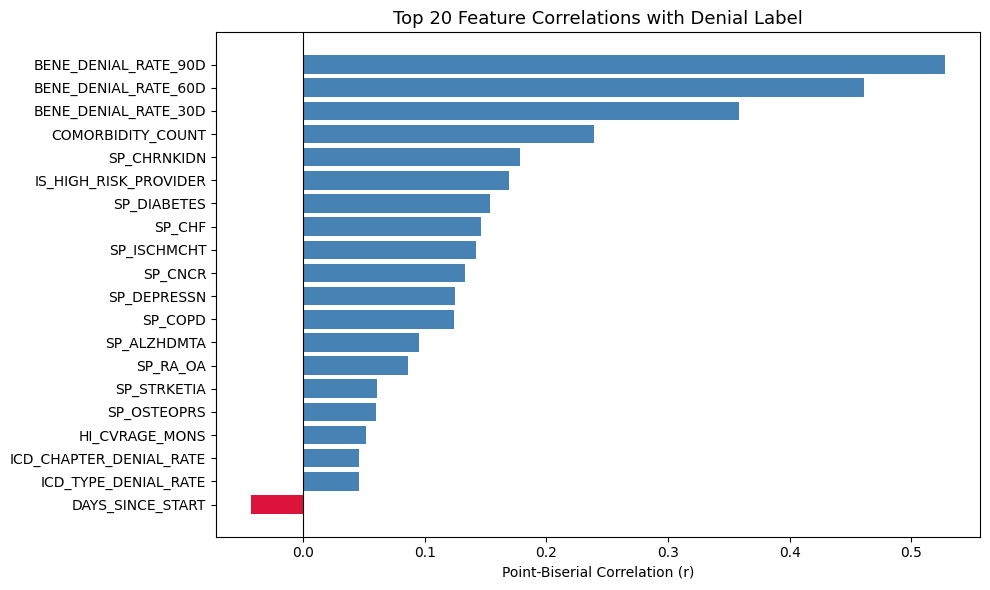

In [13]:
# Plot top 20
top20 = corr_df.head(20).copy()
colors = ['crimson' if r < 0 else 'steelblue' for r in top20['r']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top20.index[::-1], top20['r'][::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 Feature Correlations with Denial Label', fontsize=13)
ax.set_xlabel('Point-Biserial Correlation (r)')
plt.tight_layout()
plt.savefig(FIGURES / '10_feature_correlations.png', dpi=150)
plt.show()


## 7. Feature Distribution by Denial Status

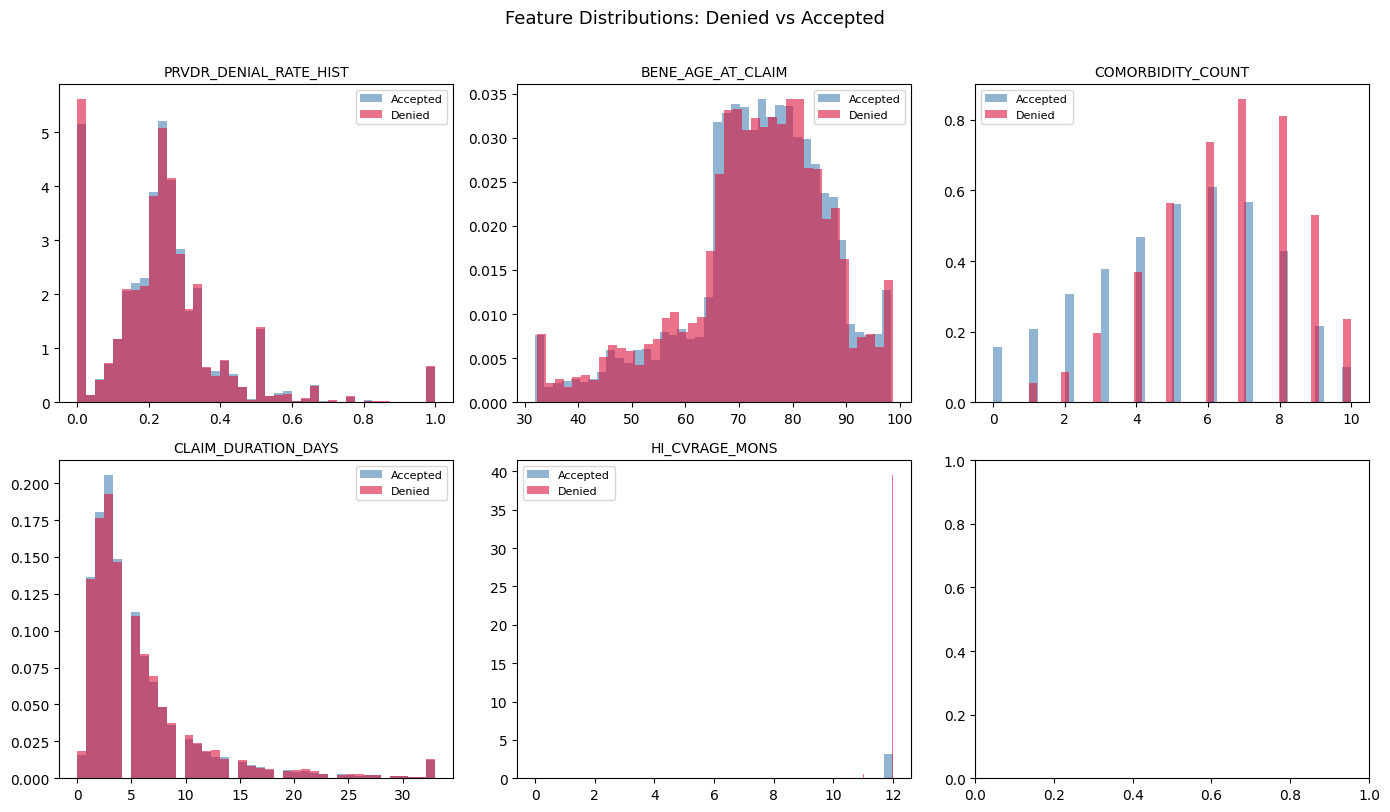

In [14]:
# Compare key feature distributions between denied and accepted claims
key_numeric = [
    'CLM_PMT_AMT_LOG', 'PRVDR_DENIAL_RATE_HIST', 'BENE_AGE_AT_CLAIM',
    'COMORBIDITY_COUNT', 'CLAIM_DURATION_DAYS', 'HI_CVRAGE_MONS'
]
key_numeric = [c for c in key_numeric if c in X_train.columns]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(key_numeric):
    ax = axes[i]
    denied_vals   = X_train.loc[y_train == 1, col].dropna()
    accepted_vals = X_train.loc[y_train == 0, col].dropna()
    ax.hist(accepted_vals.clip(
        accepted_vals.quantile(0.01), accepted_vals.quantile(0.99)
    ), bins=40, alpha=0.6, color='steelblue', label='Accepted', density=True)
    ax.hist(denied_vals.clip(
        denied_vals.quantile(0.01), denied_vals.quantile(0.99)
    ), bins=40, alpha=0.6, color='crimson', label='Denied', density=True)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions: Denied vs Accepted', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / '11_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Fill Remaining Nulls

In [15]:
# Strategy:
# - Numeric L1/L3 features: fill with median of training set
# - L2 rate features: fill with global denial rate
# - Binary flags: fill with 0

GLOBAL_DENIAL_RATE = history.get('global_denial_rate', y_train.mean())

rate_features = [c for c in X_train.columns if 'DENIAL_RATE' in c or 'DENIAL' in c]
flag_features = [c for c in X_train.columns if c.startswith('IS_') or c.startswith('HAS_') or c.startswith('SP_')]

# Compute medians from training set
median_fills = X_train.median()

def fill_nulls(X, median_fills, rate_fill, flag_features, rate_features):
    X = X.copy()
    for col in X.columns:
        if col in rate_features:
            X[col] = X[col].fillna(rate_fill)
        elif col in flag_features:
            X[col] = X[col].fillna(0)
        else:
            X[col] = X[col].fillna(median_fills.get(col, 0))
    return X

X_train = fill_nulls(X_train, median_fills, GLOBAL_DENIAL_RATE, flag_features, rate_features)
X_val   = fill_nulls(X_val,   median_fills, GLOBAL_DENIAL_RATE, flag_features, rate_features)
X_test  = fill_nulls(X_test,  median_fills, GLOBAL_DENIAL_RATE, flag_features, rate_features)

remaining_nulls = X_train.isnull().sum().sum()
print(f"Remaining nulls after fill: {remaining_nulls}")
assert remaining_nulls == 0, "Nulls remain — check fill logic!"
print("All nulls resolved ✓")


Remaining nulls after fill: 0
All nulls resolved ✓


## 9. Feature Summary

In [16]:
print(f"{'='*55}")
print(f"  FEATURE MATRIX SUMMARY")
print(f"{'='*55}")
print(f"  Train : {X_train.shape[0]:>7,} rows × {X_train.shape[1]} features")
print(f"  Val   : {X_val.shape[0]:>7,} rows × {X_val.shape[1]} features")
print(f"  Test  : {X_test.shape[0]:>7,} rows × {X_test.shape[1]} features")
print(f"{'='*55}")
print(f"  Denied (train) : {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"  Denied (val)   : {y_val.sum():,} ({y_val.mean()*100:.2f}%)")
print(f"  Denied (test)  : {y_test.sum():,} ({y_test.mean()*100:.2f}%)")
print(f"{'='*55}")
print(f"  Class imbalance ratio: {(1-y_train.mean())/y_train.mean():.1f}:1")
print()

# Feature group breakdown
l1_feats = [c for c in X_train.columns if c in [
    'CLM_PMT_AMT','NCH_PRMRY_PYR_CLM_PD_AMT','NCH_BENE_BLOOD_DDCTBL',
    'CLM_PMT_AMT_LOG','IS_SECONDARY_PAYER','IS_INPATIENT','CLAIM_DURATION_DAYS',
    'HAS_SECONDARY_DX','HAS_TERTIARY_DX','HAS_HCPCS','HCPCS_CODE_COUNT',
    'BENE_AGE_AT_CLAIM','BENE_SEX','BENE_RACE','BENE_ESRD','COMORBIDITY_COUNT',
    'HI_CVRAGE_MONS','SMI_CVRAGE_MONS','HMO_CVRAGE_MONS'] or c.startswith('SP_')]
l2_feats = [c for c in X_train.columns if 'PRVDR' in c or 'DENIAL' in c or 'BENE_DENIAL' in c]
l3_feats = [c for c in X_train.columns if any(k in c for k in ['MONTH','DOW','YEAR','QUARTER','WEEKEND','Q4','SIN','COS','DAYS_SINCE'])]
l4_feats = [c for c in X_train.columns if 'PAYER' in c or 'ICD_TYPE' in c or 'HIGH_RISK' in c]
icd_feats = [c for c in X_train.columns if c.startswith('ICD_CH')]

print(f"  L1 (claim attrs)       : {len(l1_feats)} features")
print(f"  L2 (historical aggs)   : {len(l2_feats)} features")
print(f"  L3 (temporal)          : {len(l3_feats)} features")
print(f"  L4 (interactions)      : {len(l4_feats)} features")
print(f"  ICD-9 chapter dummies  : {len(icd_feats)} features")
print(f"  Total                  : {X_train.shape[1]} features")


  FEATURE MATRIX SUMMARY
  Train :  46,693 rows × 64 features
  Val   :  10,006 rows × 64 features
  Test  :  10,006 rows × 64 features
  Denied (train) : 10,708 (22.93%)
  Denied (val)   : 1,780 (17.79%)
  Denied (test)  : 1,559 (15.58%)
  Class imbalance ratio: 3.4:1

  L1 (claim attrs)       : 26 features
  L2 (historical aggs)   : 7 features
  L3 (temporal)          : 12 features
  L4 (interactions)      : 2 features
  ICD-9 chapter dummies  : 19 features
  Total                  : 64 features


## 10. Save Feature Sets

In [17]:
# Save feature matrices as parquet
X_train_out = X_train.copy()
X_train_out['DENIED'] = y_train

X_val_out = X_val.copy()
X_val_out['DENIED'] = y_val

X_test_out = X_test.copy()
X_test_out['DENIED'] = y_test

X_train_out.to_parquet(PROC / 'features_train.parquet', index=False)
X_val_out.to_parquet(PROC   / 'features_val.parquet',   index=False)
X_test_out.to_parquet(PROC  / 'features_test.parquet',  index=False)

# Save the history dict (fitted lookups) for reproducibility
joblib.dump(history, PROC / 'feature_history.joblib')

print("Saved:")
print(f"  {PROC / 'features_train.parquet'}  ({X_train_out.memory_usage(deep=True).sum()/1e6:.1f} MB)")
print(f"  {PROC / 'features_val.parquet'}")
print(f"  {PROC / 'features_test.parquet'}")
print(f"  {PROC / 'feature_history.joblib'}")
print()
print("✓ Feature engineering complete. Ready for Notebook 03 — Baseline Model.")


Saved:
  C:\Users\Aasir Waseer\Desktop\Aasir\MDS_AI\3_Sem\rcm_project\data\processed\features_train.parquet  (24.3 MB)
  C:\Users\Aasir Waseer\Desktop\Aasir\MDS_AI\3_Sem\rcm_project\data\processed\features_val.parquet
  C:\Users\Aasir Waseer\Desktop\Aasir\MDS_AI\3_Sem\rcm_project\data\processed\features_test.parquet
  C:\Users\Aasir Waseer\Desktop\Aasir\MDS_AI\3_Sem\rcm_project\data\processed\feature_history.joblib

✓ Feature engineering complete. Ready for Notebook 03 — Baseline Model.


## 11. Feature Engineering Notes

| Layer | # Features | Key signals |
|-------|-----------|-------------|
| L1 — Claim attrs | ~25 | `CLM_PMT_AMT_LOG`, `IS_INPATIENT`, `COMORBIDITY_COUNT`, ICD flags |
| L2 — Historical | ~6 | `PRVDR_DENIAL_RATE_HIST`, `ICD_CHAPTER_DENIAL_RATE`, `BENE_DENIAL_RATE_*D` |
| L3 — Temporal | ~11 | `CLAIM_MONTH`, `CLAIM_DOW`, cyclical encodings |
| L4 — Interactions | ~3 | `PRVDR_PAYER_DENIAL_RATE`, `ICD_TYPE_DENIAL_RATE`, `IS_HIGH_RISK_PROVIDER` |
| ICD-9 dummies | ~18 | One-hot chapter encoding |

**Leakage safeguards applied:**
- L2 uses expanding-mean (shift-1) on sorted training data
- Val/test receive only lookup values from training history
- `CLM_PMT_AMT` is included as a feature but DENIED label was derived *before* feature engineering

**Next:** Notebook 03 — Logistic Regression baseline with ROC-AUC, PR curves, and calibration plots.
